In [1]:
import pandas as pd 
import numpy as np 
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib

#### STEP 1 - raw_event (원천데이터)
- 25,088행 × 23컬럼, 비정규화 상태
- 광고 정보 + 유저 정보 + 제품 정보 + 이벤트 측정값이 한 행에 혼재
- 핵심 컬럼은 `event_type` — 7가지 이벤트가 이 컬럼 하나로 구분

* impression → 광고 노출
* click → 클릭
* lead → 리드
* signup → 회원가입
* purchase → 구매 / 구독 갱신
* session → 앱 세션
* churn → 이탈

##### raw_events → dim 분리 → fact_event 생성
```
raw_events.csv (비정규화 — 25,088행 × 23컬럼)
│
│  ┌─────────────────────────────────────────────────────────────────┐
│  │ event_id  channel          campaign_name  user_id  product_name  amount_krw │
│  │ E0000001  검색광고(Google)  브랜드_검색    NULL     NULL           0          │
│  │ E0000002  검색광고(Google)  브랜드_검색    NULL     NULL           0          │
│  │ E0004393  검색광고(Google)  브랜드_검색    U000001  NULL           0          │
│  │ E0004424  오가닉            SEO_블로그     U000010  베이직 플랜    9900        │
│  └─────────────────────────────────────────────────────────────────┘
│
├── 중복 제거 + ID 부여
│
▼
dim_channel      dim_campaign     dim_user         dim_product
(5행)            (13행)           (6,570행)        (4행)
channel_id       campaign_id      user_id          product_id
CH01             CAMP001          U000001          PROD01
CH02             CAMP002          U000002          PROD02
...              ...              ...              ...
│
│  위 4개 dim의 ID를 raw의 문자열 자리에 대입
│
▼
fact_event.csv (25,088행 × 12컬럼)
┌──────────────────────────────────────────────────────────────────┐
│ event_id  channel_id  campaign_id  user_id  product_id  amount_krw │
│ E0000001  CH01        CAMP001      NULL     NULL         0          │
│ E0000002  CH01        CAMP001      NULL     NULL         0          │
│ E0004393  CH01        CAMP001      U000001  NULL         0          │
│ E0004424  CH05        CAMP012      U000010  PROD01       9900       │
└──────────────────────────────────────────────────────────────────┘
```

![dim_fact](dim_fact.png)

In [2]:
df = pd.read_csv("raw_events.csv")
df.head(3)

,event_id,event_date,event_type,user_id,user_register_date,user_cohort_month,user_cohort_week,user_device,user_os,user_age_group,...,channel,campaign_objective,ad_spend_krw,cpm_krw,event_count,product_name,product_price_krw,amount_krw,session_min,day_since_reg
0,E0000001,2024-01-01,impression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,검색광고(Google),전환,258064,5000,51391,NaN,NaN,0,NaN,NaN
1,E0000002,2024-01-01,click,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,검색광고(Google),전환,0,5000,2561,NaN,NaN,0,NaN,NaN
2,E0000003,2024-01-01,lead,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,검색광고(Google),전환,0,5000,80,NaN,NaN,0,NaN,NaN


In [3]:
# 1. dim channel 

dim_channel= df[['channel', 'campaign_objective','cpm_krw']].\
                            drop_duplicates(subset= 'channel').\
                            reset_index(drop = True) 
# Channel_Id 생성 
dim_channel['channel_id'] = [f'CH_{i+1:02d}' for i in range(len(dim_channel.index))] 

# channel map 생성
channel_map = dim_channel[['channel_id','channel','cpm_krw']].set_index('channel')['channel_id'].to_dict() 
dim_channel = dim_channel[['channel_id','channel','cpm_krw']]
print(dim_channel)



  channel_id       channel  cpm_krw
0      CH_01  검색광고(Google)     5000
1      CH_02    소셜광고(Meta)     2000
2      CH_03         인플루언서     3333
3      CH_04           이메일     1000
4      CH_05           오가닉        0


In [4]:
# 2. dim campaign 
dim_campaign  = (
                df[['campaign_name', 'channel']].
                drop_duplicates().reset_index(drop = True)
) 

dim_campaign['campaign_id'] = [f'CAMP_{i+1:03d}' for i in range(len(dim_campaign))]

# Channel_map 매핑

dim_campaign['channel_id'] = dim_campaign['channel'].map(channel_map)
dim_campaign.drop(columns = 'channel', inplace = True)
dim_campaign = dim_campaign[['campaign_id','campaign_name','channel_id']]

campaign_map = (
            df[['campaign_name','channel']].drop_duplicates().reset_index(drop = True).\
            assign(channel_id = lambda x : x['channel'].map(channel_map)).\
            merge(dim_campaign, on = ['campaign_name','channel_id']).\
            set_index('campaign_name')['campaign_id'].\
            to_dict()
)

print(dim_campaign)

   campaign_id campaign_name channel_id
0     CAMP_001       경쟁사_키워드      CH_01
1     CAMP_002        브랜드_검색      CH_01
2     CAMP_003       제품_카테고리      CH_01
3     CAMP_004       카탈로그_쇼핑      CH_02
4     CAMP_005      신규유저_이미지      CH_02
5     CAMP_006      리타겟팅_동영상      CH_02
6     CAMP_007      메가_인플루언서      CH_03
7     CAMP_008    마이크로_인플루언서      CH_03
8     CAMP_009        웰컴_시퀀스      CH_04
9     CAMP_010        재구매_유도      CH_04
10    CAMP_011         카트_복구      CH_04
11    CAMP_012       SEO_블로그      CH_05
12    CAMP_013        바이럴_공유      CH_05


In [5]:
# dim_user

dim_user = (
    df[df['event_type'] == 'signup']
    [[
        'user_id','user_register_date','user_cohort_month','user_cohort_week',
        'user_device','user_os','user_age_group','user_gender','user_region',
        'channel',
    ]].drop_duplicates(subset = 'user_id').reset_index(drop = True)
)

dim_user['channel_id'] = dim_user['channel'].map(channel_map)
dim_user.drop(columns = 'channel', inplace = True) 

dim_user.rename(columns={
    'user_register_date': 'register_date',
    'user_cohort_month' : 'cohort_month',
    'user_cohort_week'  : 'cohort_week',
    'user_device'       : 'device',
    'user_os'           : 'os',
    'user_age_group'    : 'age_group',
    'user_gender'       : 'gender',
    'user_region'       : 'region',
}, inplace=True)

dim_user

# user_map 생성 user_id, channel_id
user_channel_map = dim_user.set_index('user_id')['channel_id'].to_dict()

In [6]:
# dim product - product_name별 krw 가격

dim_product = (
    df[df['product_name'].notna()]
    [['product_name','product_price_krw']].drop_duplicates().reset_index(drop= True)
)

# product_code 생성 
dim_product['product_id'] = [f'PROD_{i+1:02d}' for i in range(len(dim_product))]

prod_map = dim_product.set_index('product_name')['product_id'].to_dict()
prod_map

{'베이직 플랜': 'PROD_01',
 '스탠다드 플랜': 'PROD_02',
 '단건 결제': 'PROD_03',
 '프리미엄 플랜': 'PROD_04'}

In [7]:
# fact 

fact = df[[
    'event_id','event_date','event_type',
    'user_id','campaign_name','channel',
    'product_name',
    'ad_spend_krw','event_count','amount_krw',
    'session_min','day_since_reg',
]].copy() 


fact

fact['channel_id'] = fact['channel'].map(channel_map)
fact['campaign_id'] = fact['campaign_name'].map(campaign_map)
fact['product_id'] = fact['product_name'].map(prod_map) 

 
# 컬럼 순서 정리
fact = fact[[
    'event_id','event_date','event_type',
    'user_id','channel_id','campaign_id','product_id',
    'ad_spend_krw','event_count','amount_krw',
    'session_min','day_since_reg',
]]

fact.head(10)

,event_id,event_date,event_type,user_id,channel_id,campaign_id,product_id,ad_spend_krw,event_count,amount_krw,session_min,day_since_reg
0,E0000001,2024-01-01,impression,NaN,CH_01,CAMP_001,NaN,258064,51391,0,NaN,NaN
1,E0000002,2024-01-01,click,NaN,CH_01,CAMP_001,NaN,0,2561,0,NaN,NaN
2,E0000003,2024-01-01,lead,NaN,CH_01,CAMP_001,NaN,0,80,0,NaN,NaN
3,E0000004,2024-01-02,impression,NaN,CH_01,CAMP_001,NaN,258064,51800,0,NaN,NaN
4,E0000005,2024-01-02,click,NaN,CH_01,CAMP_001,NaN,0,2564,0,NaN,NaN
5,E0000006,2024-01-02,lead,NaN,CH_01,CAMP_001,NaN,0,104,0,NaN,NaN
6,E0000007,2024-01-03,impression,NaN,CH_01,CAMP_001,NaN,258064,51639,0,NaN,NaN
7,E0000008,2024-01-03,click,NaN,CH_01,CAMP_001,NaN,0,2516,0,NaN,NaN
8,E0000009,2024-01-03,lead,NaN,CH_01,CAMP_001,NaN,0,86,0,NaN,NaN
9,E0000010,2024-01-04,impression,NaN,CH_01,CAMP_001,NaN,258064,51230,0,NaN,NaN


In [8]:
channel_map
inv_map = {v : k for k, v in channel_map.items()}
inv_map

cost = fact.groupby('channel_id').apply(lambda x : pd.Series({
                        '광고비' : x[x['event_type'] == 'impression']['ad_spend_krw'].sum() , 
                        '노출수' : x[x['event_type'] == 'impression']['event_count'].sum() , 
                        '클릭수' : x[x['event_type'] == 'click']['event_count'].sum() , 
                        '리드수' : x[x['event_type'] == 'lead']['event_count'].sum(), 
                        '가입수' : x[x['event_type'] == 'signup']['event_count'].sum(), 
                        '구매수' : x[x['event_type'] == 'purchase']['event_count'].sum(), 
                        '매출'   : x[x['event_type'] == 'purchase']['amount_krw'].sum()
                    })).reset_index() 

cost['channel_name'] = cost['channel_id'].astype(str).map(inv_map)
cost = cost[['channel_id','channel_name', '광고비', '노출수','클릭수','리드수','가입수','구매수','매출']]

C:\Users\i2max-DoeunKim\AppData\Local\Temp\ipykernel_30556\1228002624.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cost = fact.groupby('channel_id').apply(lambda x : pd.Series({


In [9]:
# CPM : 광고가 1000번 노출 되는데 드는 비용 
cost['CPM']  = (cost['광고비'] / cost['노출수'].replace(0,np.nan) * 1000).round(0)

# CPC : 1번 클릭하는데 드는 비용 
cost['CPC']  = (cost['광고비'] / cost['클릭수'].replace(0,np.nan)).round(0)
cost['CPC%'] = (cost['리드수'] / cost['클릭수'] * 100).round(1)

# CPL : 잠재고객 확보 비용 - 관심을 보이는 사람 1명을 확보하는데 드는 비용 
cost['CPL']  = (cost['광고비'] / cost['리드수'].replace(0,np.nan)).round(0)
# CPL% : 리드->가입전환율 (리드 질 측정) : 리드 중 실제 가입까지 이어진 비율
cost['CPL%'] = (cost['가입수'] / cost['리드수'] * 100).round(1)

# CPR : 가입 1건당 드는 비용
cost['CPR']  = (cost['광고비'] / cost['가입수'].replace(0,np.nan)).round(0)
cost['CPR%'] = (cost['구매수'] / cost['가입수'] * 100).round(1)
# CPA : 유로 고객 1명을 실제로 획득하는데 드는 비용 
# CPA < LTV (수익을 데려옴)
# CPA > LTV ->손실
cost['CPA']  = (cost['광고비'] / cost['구매수'].replace(0,np.nan)).round(0)
cost['ROAS'] = (cost['매출']   / cost['광고비'].replace(0,np.nan) * 100).round(2)

# CTR- 광고를 본 사람 중 클릭한 비율
cost['CTR']  = (cost['클릭수'] / cost['노출수'].replace(0,np.nan) * 100).round(3)
# CVR 최종 구매 전환율
cost['CVR']  = (cost['구매수'] / cost['클릭수'].replace(0,np.nan) * 100).round(4)

paid = cost[cost['광고비'] > 0].copy()

,channel_id,channel_name,광고비,노출수,클릭수,리드수,가입수,구매수,매출,CPM,CPC,CPC%,CPL,CPL%,CPR,CPR%,CPA,ROAS,CTR,CVR
0,CH_01,검색광고(Google),133999854,26800000,1340000,42880,1807,129,2342100,5000.0,100.0,3.2,3125.0,4.2,74156.0,7.1,1038759.0,1.75,5.0,0.0096
1,CH_02,소셜광고(Meta),111699876,55850000,1675500,30159,1636,70,1328000,2000.0,67.0,1.8,3704.0,5.4,68276.0,4.3,1595713.0,1.19,3.0,0.0042
2,CH_03,인플루언서,67499881,20252025,810076,17010,752,39,776100,3333.0,83.0,2.1,3968.0,4.4,89760.0,5.2,1730766.0,1.15,4.0,0.0048
3,CH_04,이메일,8299860,8300000,1245000,105825,1054,141,2990900,1000.0,7.0,8.5,78.0,1.0,7875.0,13.4,58864.0,36.04,15.0,0.0113


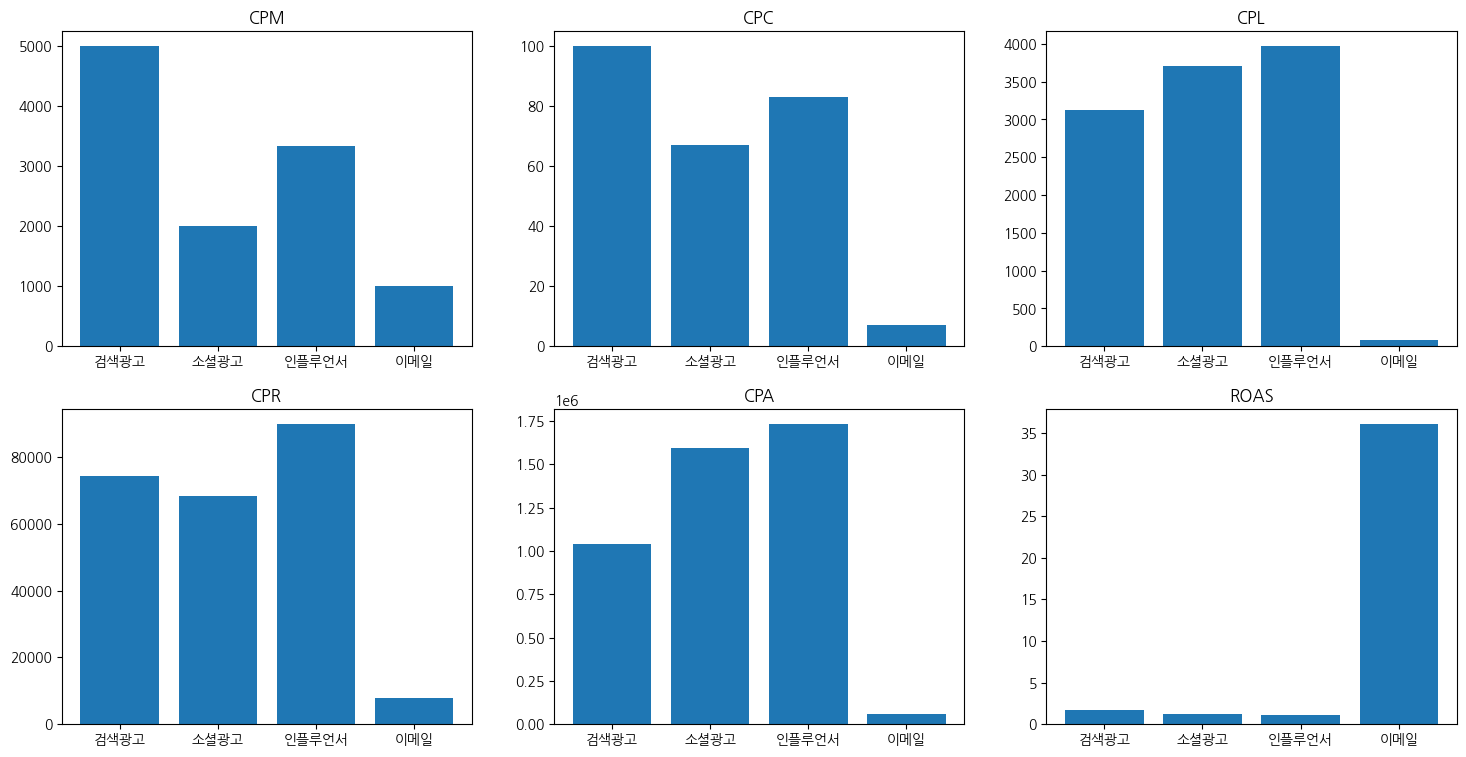

In [10]:
import warnings
warnings.filterwarnings('ignore')

display(paid)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

METRICS = [
    ('CPM',  'CPM — 1,000회 노출당 비용 (원)'),
    ('CPC',  'CPC — 클릭 1회당 비용 (원)'),
    ('CPL',  'CPL — 리드 1건당 비용 (원)'),
    ('CPR',  'CPR — 가입 1건당 비용 (원)'),
    ('CPA',  'CPA — 구매 1건당 비용 (원)  ★핵심'),
]

paid['channel_name'] = paid['channel_name'].str.replace('(Google)','').str.replace('(Meta)','')

cols = ['CPM','CPC','CPL', 'CPR','CPA','ROAS']

for axes, col in zip(axes.flatten() , cols) : 
    target = paid[['channel_name',col]]
    axes.bar(target['channel_name'] , target[col].fillna(0))
    axes.set_title(col)

plt.show() 

In [11]:
# LTV 계산 - 고객 1명이 전체 기간동안 결제한 총 금액 
# CPA (획득비용)과 함꼐 봐서 광고 수익성을 판단 

# CPA = 58.864
# LTV = 72,949

# LTV - CAP = 14,085 (순이익)
user_ltv = fact[fact['event_type'] == 'purchase'].groupby('user_id')['amount_krw'].sum().\
            reset_index().rename(columns = {'amount_krw': 'ltv'}).\
            merge(dim_user[['user_id','channel_id']], how = 'left' , on = 'user_id').\
            merge(dim_channel[['channel_id','channel']] , how = 'left', on = 'channel_id')

user_ltv.head()

,user_id,ltv,channel_id,channel
0,U000010,9900,CH_05,오가닉
1,U000038,39800,CH_03,인플루언서
2,U000063,4900,CH_01,검색광고(Google)
3,U000280,119600,CH_04,이메일
4,U000299,59700,CH_04,이메일


In [12]:
ltv_ch = user_ltv.groupby('channel').agg(
    구매유저수=('user_id','count'),
    평균LTV=('ltv','mean'), 
    중앙LTV=('ltv','median')
).round(0)
ltv_ch

,구매유저수,평균LTV,중앙LTV
channel,,,
검색광고(Google),42,55764.0,39600.0
소셜광고(Meta),24,55333.0,44550.0
오가닉,34,46947.0,24800.0
이메일,41,72949.0,59700.0
인플루언서,12,64675.0,29800.0


In [13]:
# cost table -> set_index처리
cost_idx = cost.drop(columns = 'channel_id').set_index('channel_name')

# 신규 회원 1명을 유치하는데 든 총 마케팅 비용
#CPA = 광고비 ÷ 구매수   → 유료 고객 1명 기준 (가입은 했지만 구매를 안 한 913명의 비용까지 CPA에는 포함)
#CAC = 광고비 ÷ 가입수   → 신규 회원 1명 기준
ltv_ch['CAC'] = (cost_idx['광고비'] / cost_idx['가입수'].replace(0, np.nan)).round(0)

# 고객 1명이 가져다 주는 수익이 유치 비용의 몇 배인가
ltv_ch['LTV_CAC'] = (ltv_ch['평균LTV'] / ltv_ch['CAC'].replace(0, np.nan)).round(2)
#1.0 미만  → 유치 비용 > 생애 매출  (손실)
#1.0       → 유치 비용 = 생애 매출  (본전)
#3.0 이상  → 업계 건강 기준
#5.0 이상  → 우수한 수익 구조


ltv_ch['ROI'] = ((ltv_ch['평균LTV'] - ltv_ch['CAC']) / ltv_ch['CAC'].replace(0, np.nan) * 100).round(2)

ltv_ch

# CAC = 신규 가입자 1명을 데려오는데 쓰는 광고비 
# LTC/CAC = LTV가 CAC의 몇 배인지
# ROI - 고객 1명을 데려오는데 쓴 비용 대비 순이익의 비

,구매유저수,평균LTV,중앙LTV,CAC,LTV_CAC,ROI
channel,,,,,,
검색광고(Google),42,55764.0,39600.0,74156.0,0.75,-24.80
소셜광고(Meta),24,55333.0,44550.0,68276.0,0.81,-18.96
오가닉,34,46947.0,24800.0,0.0,NaN,NaN
이메일,41,72949.0,59700.0,7875.0,9.26,826.34
인플루언서,12,64675.0,29800.0,89760.0,0.72,-27.95


<Axes: xlabel='channel'>

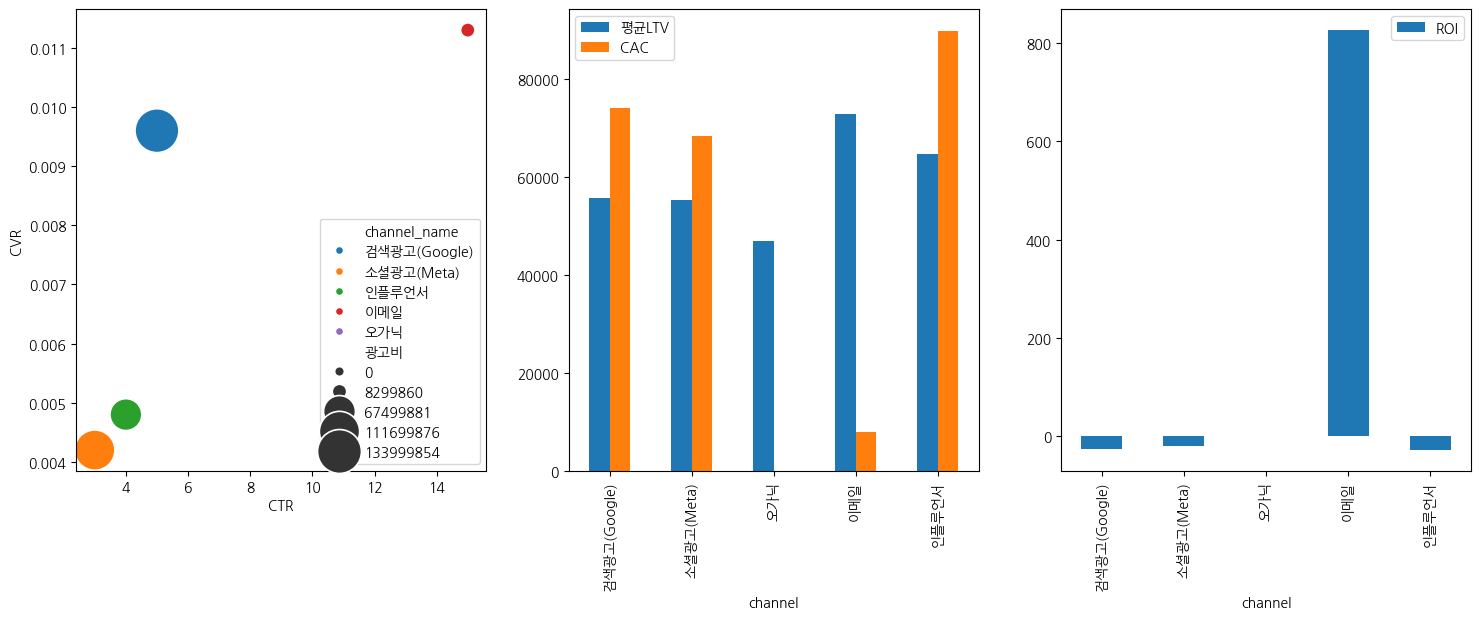

In [14]:
# CTR, CVR 버블 
import seaborn as sns 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]

sns.scatterplot(
                    data=cost_idx,
                    x='CTR',
                    y='CVR',
                    size='광고비',
                    hue='channel_name',
                    sizes=(50, 1000),
                    ax=ax
)


ax = axes[1]
ltv_ch[['평균LTV','CAC']].plot(kind = 'bar', ax = ax)

ax = axes[2]
ltv_ch[['ROI']].plot(kind = 'bar',  ax = ax)


###### ──────────────────────────────────────────────────────────────
###### [3-3]  퍼널 분석  Funnel Analysis
###### 퍼널 = 광고 노출부터 구매까지 각 단계를 거치며 줄어드는 사용자 수
###### 어느 단계에서 가장 많이 이탈하는지(병목 구간) 파악이 핵심
###### ──────────────────────────────────────────────────────────────

In [15]:
print("""
  퍼널 구조:
    [노출] → [클릭] → [리드] → [가입] → [구매]
      ↓         ↓        ↓        ↓        ↓
     CPM       CPC      CPL      CPR      CPA   ← 각 단계 비용 지표
 
  계산:
    단계 전환율 = 다음 단계 수 ÷ 현재 단계 수 × 100 (%)
    노출 대비 % = 각 단계 수 ÷ 노출수 × 100 (%)
 
  해석:
    전환율이 급격히 낮아지는 구간 = 병목(Bottleneck)
    병목 구간에 개선 리소스를 집중해야 전체 퍼널 효율 상승
""")


  퍼널 구조:
    [노출] → [클릭] → [리드] → [가입] → [구매]
      ↓         ↓        ↓        ↓        ↓
     CPM       CPC      CPL      CPR      CPA   ← 각 단계 비용 지표
 
  계산:
    단계 전환율 = 다음 단계 수 ÷ 현재 단계 수 × 100 (%)
    노출 대비 % = 각 단계 수 ÷ 노출수 × 100 (%)
 
  해석:
    전환율이 급격히 낮아지는 구간 = 병목(Bottleneck)
    병목 구간에 개선 리소스를 집중해야 전체 퍼널 효율 상승



In [16]:
stages = ['노출수','클릭수','리드수','가입수','구매수']
total_f = cost[cost['광고비']>0][stages].sum()
total_f
total_pct = (total_f / total_f['노출수'] * 100)
total_pct

overall_conv = pd.Series({
    '노출→클릭': total_f['클릭수'] / total_f['노출수'] * 100,
    '클릭→리드': total_f['리드수'] / total_f['클릭수'] * 100,
    '리드→가입': total_f['가입수'] / total_f['리드수'] * 100,
    '가입→구매': total_f['구매수'] / total_f['가입수'] * 100,
})

overall_conv

노출→클릭    4.559787
클릭→리드    3.862954
리드→가입    2.679784
가입→구매    7.220423
dtype: float64

In [17]:
paid2 = cost[cost['광고비']>0]

paid2['노출->클릭'] = (paid2['클릭수'] / paid2['노출수'] * 100).round(2)
paid2['클릭_>리드'] = (paid2['리드수'] / paid2['클릭수'] * 100).round(2)
paid2['리드->가입'] = (paid2['가입수'] / paid2['리드수'] * 100).round(2)
paid2['가입->구매'] = (paid2['구매수'] / paid2['가입수'] * 100).round(2)

paid3 = paid2[['channel_name','노출->클릭', '클릭_>리드', '리드->가입' , '가입->구매']]
paid3

,channel_name,노출->클릭,클릭_>리드,리드->가입,가입->구매
0,검색광고(Google),5.0,3.2,4.21,7.14
1,소셜광고(Meta),3.0,1.8,5.42,4.28
2,인플루언서,4.0,2.1,4.42,5.19
3,이메일,15.0,8.5,1.00,13.38


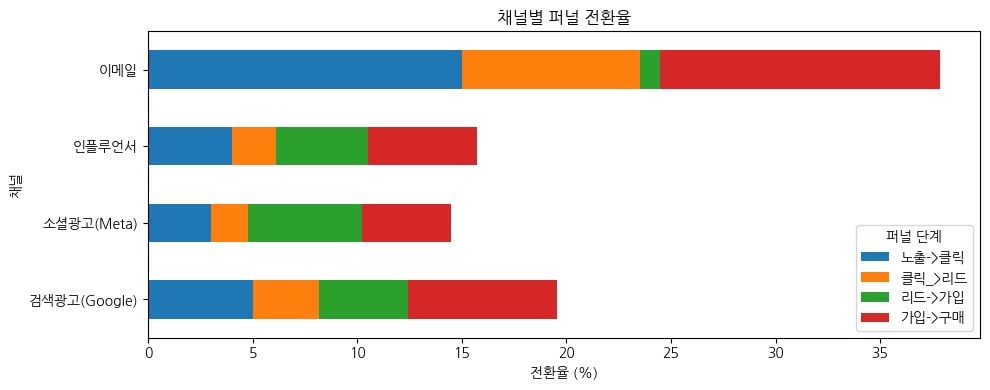

In [18]:
paid3.set_index('channel_name').plot(kind = 'barh', stacked = True, figsize=  (10, 4))
plt.title('채널별 퍼널 전환율')
plt.xlabel('전환율 (%)')
plt.ylabel('채널')
plt.legend(title='퍼널 단계')
plt.tight_layout()
plt.show()

<Axes: ylabel='channel_name'>

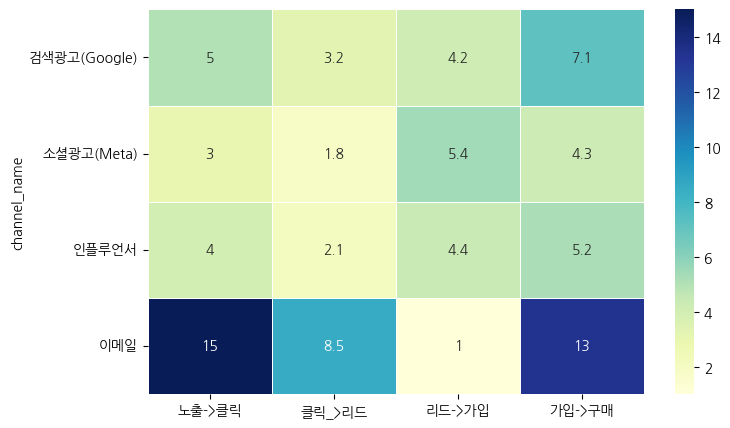

In [19]:
plt.figure(figsize=(8,5))

sns.heatmap(
    paid3.set_index('channel_name'),
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5 )
     

#### **3-4 A/B 테스트 - 캠페인 간 전환율 비교**

In [20]:
print("""
  검정 방법: 카이제곱 검정 (Chi-square Test)
  적용 이유: 가입 여부가 이분형(0/1) 데이터이므로
             두 집단 간 비율 차이의 유의성 검정에 적합
  귀무가설: 두 캠페인의 가입 전환율에 차이가 없다
  유의수준: α = 0.05
  판정 기준:
    p < 0.05 → 차이가 통계적으로 유의미 → 예산 재배분 근거 확보
    p ≥ 0.05 → 우연일 가능성 → 데이터 추가 수집 후 재검정
""")


  검정 방법: 카이제곱 검정 (Chi-square Test)
  적용 이유: 가입 여부가 이분형(0/1) 데이터이므로
             두 집단 간 비율 차이의 유의성 검정에 적합
  귀무가설: 두 캠페인의 가입 전환율에 차이가 없다
  유의수준: α = 0.05
  판정 기준:
    p < 0.05 → 차이가 통계적으로 유의미 → 예산 재배분 근거 확보
    p ≥ 0.05 → 우연일 가능성 → 데이터 추가 수집 후 재검정



In [21]:
# 캠페인별 집계
camp_agg = df.groupby(['channel','campaign_name']).apply(lambda g: pd.Series({
    '클릭수': g[g['event_type']=='click' ]['event_count'].sum(),
    '가입수': g[g['event_type']=='signup']['event_count'].sum(),
    '구매수': g[g['event_type']=='purchase']['event_count'].sum(),
    '광고비': g[g['event_type']=='impression']['ad_spend_krw'].sum(),
})).reset_index()

camp_agg['가입률'] = (camp_agg['가입수'] / camp_agg['클릭수'] * 100).round(3)
camp_agg['구매율'] = (camp_agg['구매수'] / camp_agg['가입수'] * 100).round(3)
camp_agg

,channel,campaign_name,클릭수,가입수,구매수,광고비,가입률,구매율
0,검색광고(Google),경쟁사_키워드,740000,609,28,73999913,0.082,4.598
1,검색광고(Google),브랜드_검색,277000,638,60,27699942,0.230,9.404
2,검색광고(Google),제품_카테고리,323000,560,41,32299999,0.173,7.321
3,소셜광고(Meta),리타겟팅_동영상,585000,548,21,38999932,0.094,3.832
4,소셜광고(Meta),신규유저_이미지,135000,554,28,9000000,0.410,5.054
5,소셜광고(Meta),카탈로그_쇼핑,955500,534,21,63699944,0.056,3.933
6,오가닉,SEO_블로그,0,671,31,0,inf,4.620
7,오가닉,바이럴_공유,0,650,57,0,inf,8.769
8,이메일,웰컴_시퀀스,525000,355,50,3499944,0.068,14.085
9,이메일,재구매_유도,450000,357,36,2999937,0.079,10.084


In [22]:
from itertools import combinations
from scipy import stats 

#  	검색광고(Google)	3개의 캠페인에 대한 카이제곱 검정 
target = camp_agg[camp_agg['channel'].str.split('(').str[0] == '검색광고']

res = []
for v1, v2 in combinations(target['campaign_name'], 2) : 
    t1 = target[target['campaign_name'] == v1].iloc[0]
    t2 = target[target['campaign_name'] == v2].iloc[0]

    table = [
        [t1['가입수'] , t1['클릭수'] - t1['가입수']] , 
        [t2['가입수'] , t2['클릭수'] - t2['가입수']]
    ]

    chi, p_val, _ , _ = stats.chi2_contingency(table)
    decision = '캠페인 간 가입률의 차이가 있다' if p_val < 0.05 else '캠페인 간 가입률의 차이가 없다'
    res.append([v1,v2, p_val, decision])

res = pd.DataFrame(res, columns = ['v1','v2','p_val','decision'])
res

,v1,v2,p_val,decision
0,경쟁사_키워드,브랜드_검색,3.759337e-80,캠페인 간 가입률의 차이가 있다
1,경쟁사_키워드,제품_카테고리,1.245640e-38,캠페인 간 가입률의 차이가 있다
2,브랜드_검색,제품_카테고리,9.704275e-07,캠페인 간 가입률의 차이가 있다


<Axes: xlabel='campaign_name'>

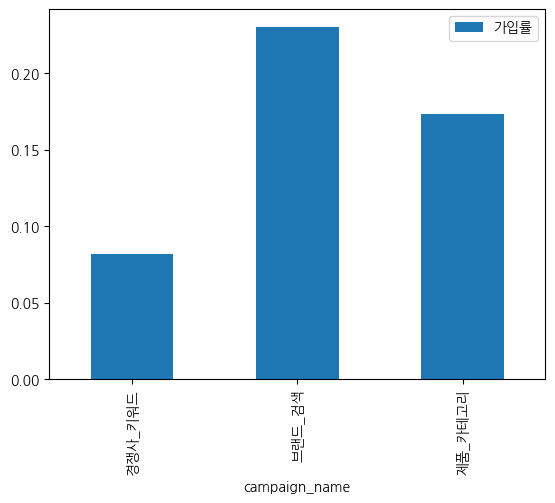

In [23]:
camp_plot = camp_agg[camp_agg['channel'].str.split('(').str[0] == '검색광고'][['campaign_name','가입률']]
camp_plot.set_index('campaign_name').plot(kind = 'bar')

In [24]:
print("  [3-5]  코호트 분석 — DAY-N 리텐션 / 월별 매트릭스")
print("""
  계산식:
    DAY-N 리텐션 = N일째 세션 유저수 ÷ 전체 가입자수 × 100%
    day_since_reg = 가입일로부터 경과 일수 (session 이벤트에 기록)
    월별 코호트  = 같은 달 가입자 그룹의 M+N 시점 잔류율
 
  해석:
    Day1  낮음 → 온보딩 경험 개선 필요 (첫날이 장기 리텐션 결정)
    Day30 = 진짜 충성 유저 비율 (업계 기준 5~8%)
    M+N이 갈수록 개선되면 → 제품 개선 또는 코호트 품질 향상 신호
""")

  [3-5]  코호트 분석 — DAY-N 리텐션 / 월별 매트릭스

  계산식:
    DAY-N 리텐션 = N일째 세션 유저수 ÷ 전체 가입자수 × 100%
    day_since_reg = 가입일로부터 경과 일수 (session 이벤트에 기록)
    월별 코호트  = 같은 달 가입자 그룹의 M+N 시점 잔류율
 
  해석:
    Day1  낮음 → 온보딩 경험 개선 필요 (첫날이 장기 리텐션 결정)
    Day30 = 진짜 충성 유저 비율 (업계 기준 5~8%)
    M+N이 갈수록 개선되면 → 제품 개선 또는 코호트 품질 향상 신호



  [전체 DAY-N 리텐션 (%)]


,0,1,2,3,4,5,6,7,8
Day,Day0,Day1,Day3,Day7,Day14,Day30,Day60,Day90,Day180
DAY_N_Retention,100.0,43.44,24.44,15.01,10.61,2.44,6.16,3.9,1.13


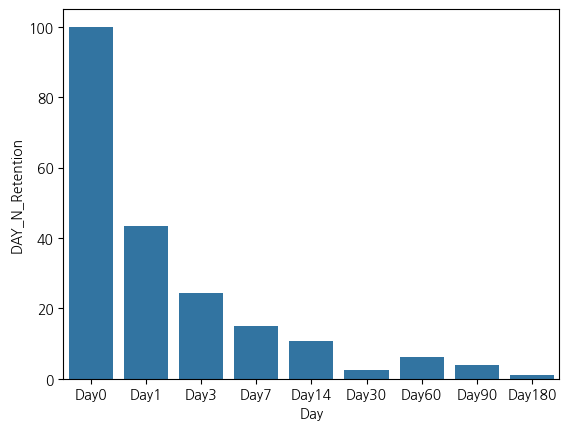

In [25]:
sessions = df[df['event_type'] == 'session'].reset_index(drop = True)
check = sessions['day_since_reg'].unique().tolist() 

total_user = len(dim_user)

day_all = {}
for d in check : 
    n = sessions[sessions['day_since_reg'] == d]['user_id'].nunique() 
    day_all[d] = round(n / total_user * 100 ,2)

print("  [전체 DAY-N 리텐션 (%)]")

dayn = pd.DataFrame()
#dayn['Day'] = pd.DataFrame({f'Day{int(day)}' for day, n in day_all.items()})
#dayn['Day'].sort_values()

reg_day = sorted([day for day, n in day_all.items()])
dayn['Day'] = [f'Day{int(day)}'for day in reg_day ]
dayn['DAY_N_Retention'] = [value for day, value in day_all.items()]

sns.barplot(x = 'Day', y = 'DAY_N_Retention' , data = dayn)
display(dayn.T)


In [26]:
print("\n  [채널별 DAY-N 리텐션 (%)]")
# 채널별 전체 유저 수 
base = sessions.groupby('channel')['user_id'].nunique().reset_index()

ch_dayn = sessions.groupby(['channel','day_since_reg'])['user_id'].nunique().reset_index()

ch_ = ch_dayn.merge(base, how = 'left' , on = 'channel')
ch_['channel_dayn_retention'] = round(ch_['user_id_x'] / ch_['user_id_y'] * 100,2) 

# 채널별 DAY-N 리텐션 (%)
ch_[['channel','day_since_reg' ,'channel_dayn_retention']].pivot(index = 'channel', columns = 'day_since_reg')


  [채널별 DAY-N 리텐션 (%)]


channel_dayn_retention                                          \
day_since_reg                  0.0    1.0    3.0    7.0    14.0  30.0  60.0    
channel                                                                        
검색광고(Google)                   100.0  44.38  24.96  15.88  10.13  6.09  3.71   
소셜광고(Meta)                     100.0  40.65  23.41  14.24  10.02  6.05  3.79   
오가닉                            100.0  45.65  26.87  15.67  11.28  6.36  4.09   
이메일                            100.0  44.78  21.92  14.42  11.48  5.50  4.17   
인플루언서                          100.0  41.49  24.73  14.23  10.64  7.18  3.86   

                           
day_since_reg 90.0  180.0  
channel                    
검색광고(Google)   3.15  1.11  
소셜광고(Meta)     1.96  0.92  
오가닉            2.20  1.06  
이메일            2.75  1.52  
인플루언서          1.73  1.20

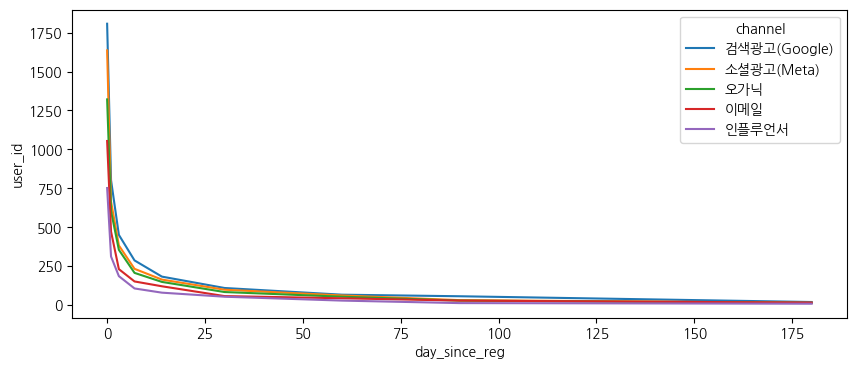

In [47]:
plt.figure(figsize=(10, 4))

# ③ lineplot
sns.lineplot(
    x='day_since_reg',
    y='user_id',
    hue='channel',
    data=ch_dayn
)

plt.show()

In [28]:
# 월별 전체 유저 수 
cohort_size = dim_user.groupby('cohort_month')['user_id'].nunique()

# sessions
s = sessions[sessions['user_cohort_month'].notna()]
s['cohort_month_ts'] = pd.to_datetime(s['user_cohort_month'])

s['period_idx'] = (
    pd.to_datetime(s['event_date']).dt.to_period('M').astype(int) -
    s['cohort_month_ts'].dt.to_period('M').astype(int)
)



In [29]:
s['cohort_month_str']= s['cohort_month_ts'].dt.month.astype(str)

In [30]:
month_cohort = s.groupby(['user_cohort_month' ,'period_idx'])['user_id'].nunique().reset_index()

month_cohort = month_cohort.merge(cohort_size, how = 'left', left_on = 'user_cohort_month', right_on = 'cohort_month')

month_cohort['month_retention'] = round(month_cohort['user_id_x'] / month_cohort['user_id_y'] * 100 , 2)


period_idx,0,1,2,3,5,6
user_cohort_month,,,,,,
2024-01,100.0,13.46,4.81,4.17,0.32,2.24
2024-02,100.0,16.11,3.69,3.36,0.34,2.68
2024-03,100.0,13.16,6.32,3.95,0.26,3.16
2024-04,100.0,15.68,5.23,2.85,0.24,2.85
2024-05,100.0,16.56,4.73,3.66,0.43,2.37
2024-06,100.0,14.34,7.77,3.98,0.60,1.79
2024-07,100.0,12.76,5.23,3.97,1.26,0.00
2024-08,100.0,14.18,6.45,4.24,0.00,0.00
2024-09,100.0,13.73,5.56,3.10,0.00,0.00


<Axes: xlabel='period_idx', ylabel='user_cohort_month'>

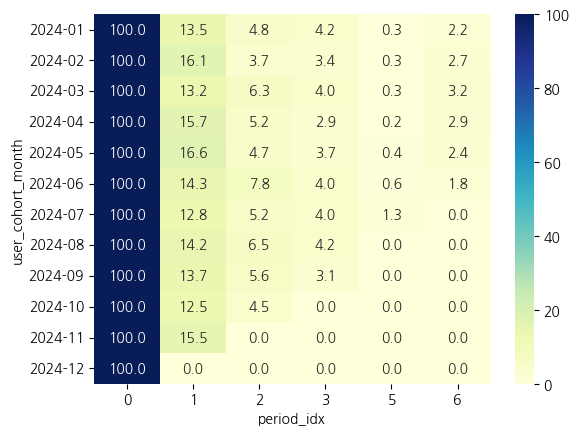

In [31]:
pivot_month_cohort_retention = month_cohort.pivot(index = 'user_cohort_month', columns = 'period_idx', values = 'month_retention').fillna(0)
display(pivot_month_cohort_retention)

sns.heatmap(pivot_month_cohort_retention , 
           annot = True, 
           fmt=".1f",
           cmap='YlGnBu'
)

In [32]:
print("  [3-6]  수명 분석 — Product Lifetime / User Lifetime")
print("─" * 66)
print("""
  계산식:
    Product Lifetime = churn 날짜 - 첫 purchase 날짜 (일수)
      이탈 없는 경우 분석 종료일(2025-01-01)까지를 유지로 간주
      → 길수록 구독이 잘 유지됨 → LTV 높음
 
    User Lifetime = 마지막 session - 첫 session (일수)
      → 앱을 얼마나 오래 사용하는가
      D30이상율 = 30일 이상 활동 유저 비율 → 중장기 잔류 가능성
""")

  [3-6]  수명 분석 — Product Lifetime / User Lifetime
──────────────────────────────────────────────────────────────────

  계산식:
    Product Lifetime = churn 날짜 - 첫 purchase 날짜 (일수)
      이탈 없는 경우 분석 종료일(2025-01-01)까지를 유지로 간주
      → 길수록 구독이 잘 유지됨 → LTV 높음
 
    User Lifetime = 마지막 session - 첫 session (일수)
      → 앱을 얼마나 오래 사용하는가
      D30이상율 = 30일 이상 활동 유저 비율 → 중장기 잔류 가능성



In [33]:
# 구매 유저 
pur = fact[fact['event_type'] == 'purchase'][['user_id','product_id','event_date']]

# 이탈 유저 
churn = fact[fact['event_type'] == 'churn'][['user_id','product_id','event_date']].\
        rename(columns = {'event_date': 'churn_date'}) 

In [34]:
# 구매 - 유저별 첫 구매 일자 
first_pur = pur.groupby(['user_id','product_id'])['event_date'].min().reset_index()

In [35]:
# user_ltv 

ltv = (
    fact[fact['event_type'] == 'purchase'].\
        groupby(['user_id','product_id'])['amount_krw'].\
        sum().reset_index().\
        rename(columns = {'amount_krw' : 'ltv'})
)

product_ltv = ltv.merge(dim_product[['product_id','product_name']], how = 'left', on = 'product_id')

In [36]:
product_ltv_agg = product_ltv.groupby(['product_id','product_name'])['ltv'].agg(
                평균LTV = 'mean',
                중앙LTV = 'median'
            ).round(0).reset_index()
# 상품별 평균, 중앙 LTV 
product_ltv_agg = product_ltv_agg[['product_name','평균LTV','중앙LTV']]

In [37]:
import numpy as np
# merge 
prod_df = first_pur.merge(churn, how = 'left', on = ['user_id','product_id']).\
                    merge(dim_product, how = 'left', on = ['product_id'])
prod_df['life_days'] = (
                        pd.to_datetime(prod_df['churn_date'].fillna(pd.Timestamp('2025-01-01'))) - 
                        pd.to_datetime(prod_df['event_date'])
                        ).dt.days

product_lifetime = prod_df.groupby('product_name')['life_days'].agg(
                                                건수 = 'count', 
                                                평균일수 = 'mean', 
                                                중앙값일수 = 'median', 
                                                Q1 = lambda x : np.percentile(x, 25) , 
                                                Q3 = lambda x : np.percentile(x, 75),
                                                IQR =lambda x: np.percentile(x,75) - np.percentile(x, 25)).reset_index()

p_life = product_lifetime.merge(product_ltv_agg, how = 'left', on = 'product_name')
print('''제품별 Product Lifetime''')
display(p_life)

제품별 Product Lifetime


,product_name,건수,평균일수,중앙값일수,Q1,Q3,IQR,평균LTV,중앙LTV
0,단건 결제,30,145.733333,141.0,72.00,209.75,137.75,4900.0,4900.0
1,베이직 플랜,44,78.340909,74.0,38.75,122.00,83.25,27675.0,24750.0
2,스탠다드 플랜,47,101.340426,92.0,62.50,146.00,83.50,72826.0,59700.0
3,프리미엄 플랜,32,122.500000,129.0,38.75,183.00,144.25,132681.0,134550.0


<Axes: title={'center': 'life_days'}, xlabel='product_name'>

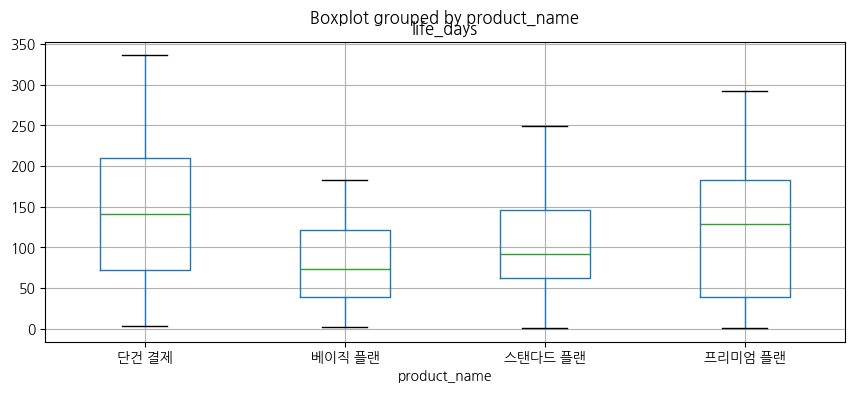

In [38]:
# Product Lifetime 박스플롯 
prod_df.boxplot(column='life_days', by='product_name', figsize=(10,4))

In [39]:
print('''
Product Lifetime 
- 고객이 특정 제품을 구매한 날부터 이탈 (구독해지)한 날짜까지의 기간 

제품별 Lifetime X LTV와의 관계
- lifetime이 길수록 LTV가 높다. 프리미엄 플랜의 LTV은 베이직의 4배 

가장 긴 lieftime은 프리미엄 플랜 (123일)
- 오래 쓸 수록 서비스에 깊게 의존하기 때문에, 프리미엄 해지 의사 결정에 비용이 높아져 장기 유지 

베이직 플랜 44명 전체를 스탠다드로 업셀하면:
  Lifetime  78일 → 101일  (+23일)
  LTV    27,675원 → 72,826원  (+45,151원/명)
  전체 추가 수익 = 44명 × 45,151원 = 약 199만원 추가
  (별도 광고비 없이)

베이직 → 프리미엄 업셀하면:
  LTV 증가 = 44명 × 105,006원 = 약 462만원 추가


베이직 플랜 Q1 = 39일 → 이탈이 39일 이전에 집중
따라서 30일 시점에 업셀 이메일 발송이 최적

목적: 이탈 직전 구간에서 상위 플랜으로 전환 유도

''')


Product Lifetime 
- 고객이 특정 제품을 구매한 날부터 이탈 (구독해지)한 날짜까지의 기간 

제품별 Lifetime X LTV와의 관계
- lifetime이 길수록 LTV가 높다. 프리미엄 플랜의 LTV은 베이직의 4배 

가장 긴 lieftime은 프리미엄 플랜 (123일)
- 오래 쓸 수록 서비스에 깊게 의존하기 때문에, 프리미엄 해지 의사 결정에 비용이 높아져 장기 유지 

베이직 플랜 44명 전체를 스탠다드로 업셀하면:
  Lifetime  78일 → 101일  (+23일)
  LTV    27,675원 → 72,826원  (+45,151원/명)
  전체 추가 수익 = 44명 × 45,151원 = 약 199만원 추가
  (별도 광고비 없이)

베이직 → 프리미엄 업셀하면:
  LTV 증가 = 44명 × 105,006원 = 약 462만원 추가


베이직 플랜 Q1 = 39일 → 이탈이 39일 이전에 집중
따라서 30일 시점에 업셀 이메일 발송이 최적

목적: 이탈 직전 구간에서 상위 플랜으로 전환 유도




In [40]:
#채널별 User Lifetime 

sess = fact[fact['event_type'] == 'session'].groupby(['user_id'])['event_date']\
                                            .agg(first= 'min', last = 'max')

sess['first'] = pd.to_datetime(sess['first'])
sess['last'] = pd.to_datetime(sess['last'])

span = sess.assign(life_day = lambda x : (x['last'] - x['first']).dt.days)\
           .merge(dim_user[['user_id', 'channel_id']], how = 'left' , on = 'user_id')\
           .merge(dim_channel, how = 'left' , on = 'channel_id')

ul_sum  = span.groupby('channel')['life_day'].agg(
    유저수 = 'count', 
    평균활동일 = 'mean', 
    중앙값활동일 = 'median' , 
    D30이상율 = lambda x : (x>=30).mean() * 100, 
    D90이상율 = lambda x : (x>=90).mean() * 100
)
ul_sum

,유저수,평균활동일,중앙값활동일,D30이상율,D90이상율
channel,,,,,
검색광고(Google),1807,11.249032,1.0,13.171002,4.205866
소셜광고(Meta),1636,10.038509,1.0,12.163814,2.872861
오가닉,1321,10.729750,3.0,12.490537,3.179410
이메일,1054,12.005693,1.0,13.377609,4.269450
인플루언서,752,10.783245,1.0,13.696809,2.925532


<Axes: xlabel='channel'>

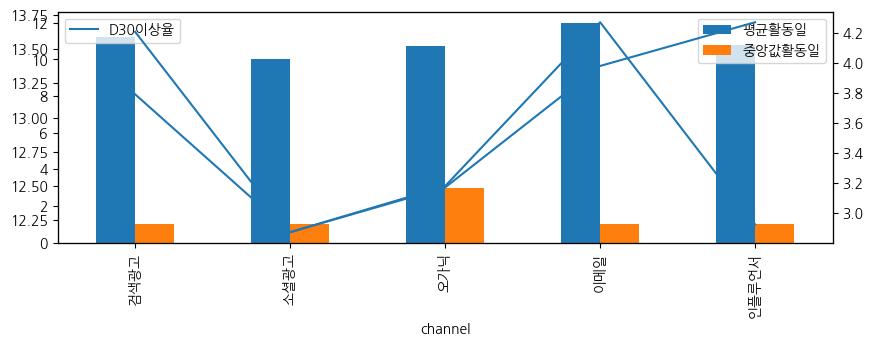

In [41]:
fig, ax1 = plt.subplots(figsize=(10,3))

ul_plot = ul_sum.reset_index().copy()
ul_plot['channel'] = ul_plot['channel'].str.split('(').str[0]

ul_plot.set_index('channel')[['평균활동일','중앙값활동일']].plot(kind = 'bar', ax = ax1)
ax1.legend()

ax2 = ax1.twinx()
ul_plot.set_index('channel')['D30이상율'].plot(kind = 'line')
ax2.legend()

ax3 = ax2.twinx()
ul_plot.set_index('channel')['D90이상율'].plot(kind = 'line')


In [42]:
print("  [3-7]  Monthly Spend & Revenue Trends")
print("─" * 66)
print("""
  계산식:
    Monthly Spend   = 월별 impression 행의 ad_spend_krw 합산
    Monthly Revenue = 월별 purchase 행의 amount_krw 합산
    Monthly ROAS    = 월별 매출 ÷ 월별 광고비 × 100%
    Monthly CPA     = 월별 광고비 ÷ 월별 구매수
    Monthly CTR     = 월별 클릭수 ÷ 월별 노출수 × 100%
    Monthly CVR     = 월별 구매수 ÷ 월별 클릭수 × 100%
 
  해석:
    Spend↑ & Revenue↑ 함께 상승 → 건강한 성장
    Spend↑ & Revenue 정체         → 광고 효율 저하 신호
    ROAS 추이                      → 월별 광고 수익성 개선 여부
    CPA 추이                       → 고객 획득 비용 최적화 진행 여부
""")

  [3-7]  Monthly Spend & Revenue Trends
──────────────────────────────────────────────────────────────────

  계산식:
    Monthly Spend   = 월별 impression 행의 ad_spend_krw 합산
    Monthly Revenue = 월별 purchase 행의 amount_krw 합산
    Monthly ROAS    = 월별 매출 ÷ 월별 광고비 × 100%
    Monthly CPA     = 월별 광고비 ÷ 월별 구매수
    Monthly CTR     = 월별 클릭수 ÷ 월별 노출수 × 100%
    Monthly CVR     = 월별 구매수 ÷ 월별 클릭수 × 100%
 
  해석:
    Spend↑ & Revenue↑ 함께 상승 → 건강한 성장
    Spend↑ & Revenue 정체         → 광고 효율 저하 신호
    ROAS 추이                      → 월별 광고 수익성 개선 여부
    CPA 추이                       → 고객 획득 비용 최적화 진행 여부



In [43]:
fact['month'] = pd.to_datetime(fact['event_date']).dt.to_period('M')

m_agg =  fact.groupby('month').apply(lambda g: pd.Series({
        '광고비' : g[g['event_type']=='impression']['ad_spend_krw'].sum(),
        '노출수' : g[g['event_type']=='impression']['event_count'].sum(),
        '클릭수' : g[g['event_type']=='click'     ]['event_count'].sum(),
        '구매수' : g[g['event_type']=='purchase'  ]['event_count'].sum(),
        '매출'   : g[g['event_type']=='purchase'  ]['amount_krw'].sum(),
    }))

In [44]:
m_agg['ROAS'] = round(m_agg['매출'] / m_agg['광고비'] * 100, 2)
m_agg['CPA'] = round(m_agg['광고비'] / m_agg['구매수'] , 2)
m_agg['CTR'] = round(m_agg['클릭수'] / m_agg['노출수'] * 100, 2)
m_agg['CVR'] = round(m_agg['구매수'] / m_agg['클릭수'] * 100, 2)
m_agg

,광고비,노출수,클릭수,구매수,매출,ROAS,CPA,CTR,CVR
month,,,,,,,,,
2024-01,17499965,6000090,281003,6,94400,0.54,2916660.83,4.68,0.00
2024-02,17899960,6140090,286003,10,159000,0.89,1789996.00,4.66,0.00
2024-03,20499959,7000120,318004,14,258600,1.26,1464282.79,4.54,0.00
2024-04,21599970,7450120,345504,19,328100,1.52,1136840.53,4.64,0.01
2024-05,23599928,8100150,370006,27,457300,1.94,874071.41,4.57,0.01
2024-06,25099980,8700150,390006,35,666500,2.66,717142.29,4.48,0.01
2024-07,23399947,8160135,369505,46,905400,3.87,508694.50,4.53,0.01
2024-08,26199929,9150150,417506,50,995000,3.80,523998.58,4.56,0.01
2024-09,28699980,9900180,447007,58,1144200,3.99,494827.24,4.52,0.01


<Axes: xlabel='month', ylabel='매출'>

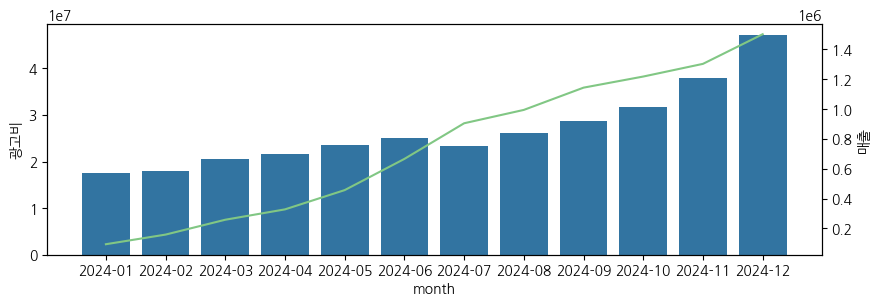

In [45]:
fig, ax1 = plt.subplots(figsize=(10,3))

m_agg_plot = m_agg.reset_index()
m_agg_plot['month'] = m_agg_plot['month'].astype(str)

sns.barplot(x = 'month', y = '광고비' , data = m_agg_plot, ax = ax1)
# 이중축
ax2 = ax1.twinx()
sns.lineplot(x = 'month', y = '매출' , color='#81c784', data = m_agg_plot, ax = ax2)



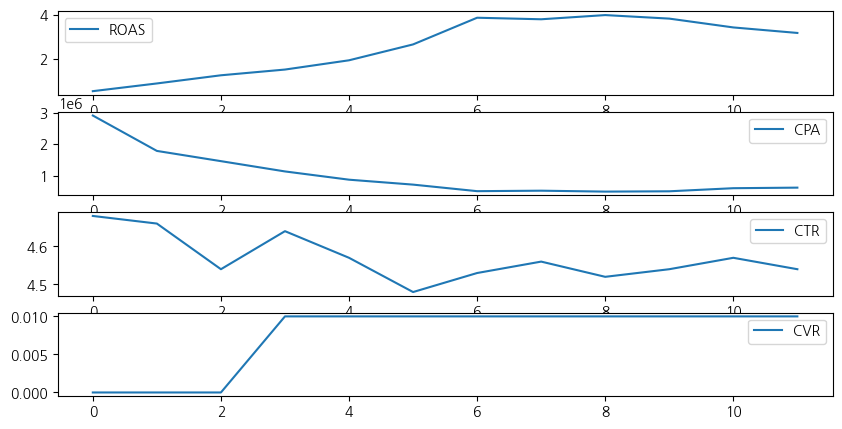

In [46]:
# 차트 
m_agg_plot = m_agg_plot.reset_index()

fig, axes = plt.subplots(4, 1, figsize =(10, 5))

for axes, col in zip(axes.flatten() , m_agg_plot[['ROAS','CPA','CTR','CVR']]) : 
    target = m_agg_plot[['month', col]]
    target.plot(kind = 'line',  ax = axes)

plt.show()